# 02. Augmentation Ablation (E1)

**Research question:** does training-time augmentation improve generalisation, and in particular
does it close the gap between `lab` (studio, controlled lighting) and `field` (real-world, phone
camera) test performance?

**Controlled setup.** Both runs below use the exact same custom CNN (`src/models/baseline_cnn.py`),
the same locked `data/splits/{train,val,test}.csv` (6,757 images, 30 classes), the same seed (42),
and identical hyperparameters (image size 128, batch size 32, AdamW lr=1e-3, weight_decay=1e-4,
**30 epochs**). **The only thing that changes between the two runs is whether training-time
augmentation** (`src/data/transforms.py`: random crop, horizontal flip, brightness/contrast jitter)
**is enabled.** Validation/test transforms are always deterministic (resize + center pad, no
randomness) for both runs, so the comparison is fair.

> **Revision note:** an earlier version of this ablation used only 10 epochs and found augmentation
> looked strictly worse (71.8% vs 61.4%). That budget was flagged as too short to draw a real
> conclusion from — augmentation makes each epoch's task harder, so the augmented run needed more
> time to catch up. This notebook reruns both variants at 30 epochs (matching the Baseline model's
> own training budget) to check whether that gap actually closes.

## Training commands

Training itself runs through the shared trainer (`src/training/trainer.py`, via
`part1_custom_cnn.py`) rather than inside this notebook, since each run takes over 10 minutes and
the trainer already writes standardized `metrics.csv` / `summary.json` / `best_custom_cnn.pt`
outputs. The two commands below are exactly what produced the results loaded further down:

```bash
python3 part1_custom_cnn.py --use-splits --split-dir data/splits --no-augmentation \
  --epochs 30 --batch-size 32 --image-size 128 --learning-rate 0.001 --weight-decay 0.0001 \
  --seed 42 --output-dir outputs/part2_augmentation_30ep/no_aug

python3 part1_custom_cnn.py --use-splits --split-dir data/splits \
  --epochs 30 --batch-size 32 --image-size 128 --learning-rate 0.001 --weight-decay 0.0001 \
  --seed 42 --output-dir outputs/part2_augmentation_30ep/aug
```

This cell loads the resulting `metrics.csv` histories for both runs directly from
`outputs/part2_augmentation_30ep/`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

no_aug_history = pd.read_csv(REPO_ROOT / "outputs/part2_augmentation_30ep/no_aug/metrics.csv")
aug_history = pd.read_csv(REPO_ROOT / "outputs/part2_augmentation_30ep/aug/metrics.csv")

no_aug_history["variant"] = "no_augmentation"
aug_history["variant"] = "augmentation"
history = pd.concat([no_aug_history, aug_history], ignore_index=True)
history.pivot(index="epoch", columns="variant", values="val_acc")

variant,augmentation,no_augmentation
epoch,,
1,0.150685,0.172211
2,0.181018,0.250489
3,0.346380,0.375734
4,0.309198,0.483366
5,0.421722,0.328767
6,0.394325,0.574364
7,0.473581,0.641879
8,0.532290,0.554795
9,0.497065,0.682975


## Test-set results, overall and by source

`test_lab_acc` / `test_field_acc` are computed by loading each run's best checkpoint
(`best_custom_cnn.pt`, selected on validation accuracy — the test set was touched exactly once per
variant) and evaluating on the held-out test split, broken down by whether the image came from
`lab` or `field`. This directly answers the E1 research question about field robustness.

In [2]:
ablation = pd.read_csv(REPO_ROOT / "data/metadata/augmentation_ablation.csv")
ablation

,variant,epochs,best_val_acc,test_overall_acc,test_macro_f1,test_lab_acc,test_field_acc,elapsed_minutes
0,no_augmentation,30,0.921722,0.915085,0.916293,0.934211,0.854772,13.223156
1,augmentation,30,0.863014,0.868132,0.874167,0.885526,0.813278,13.795450


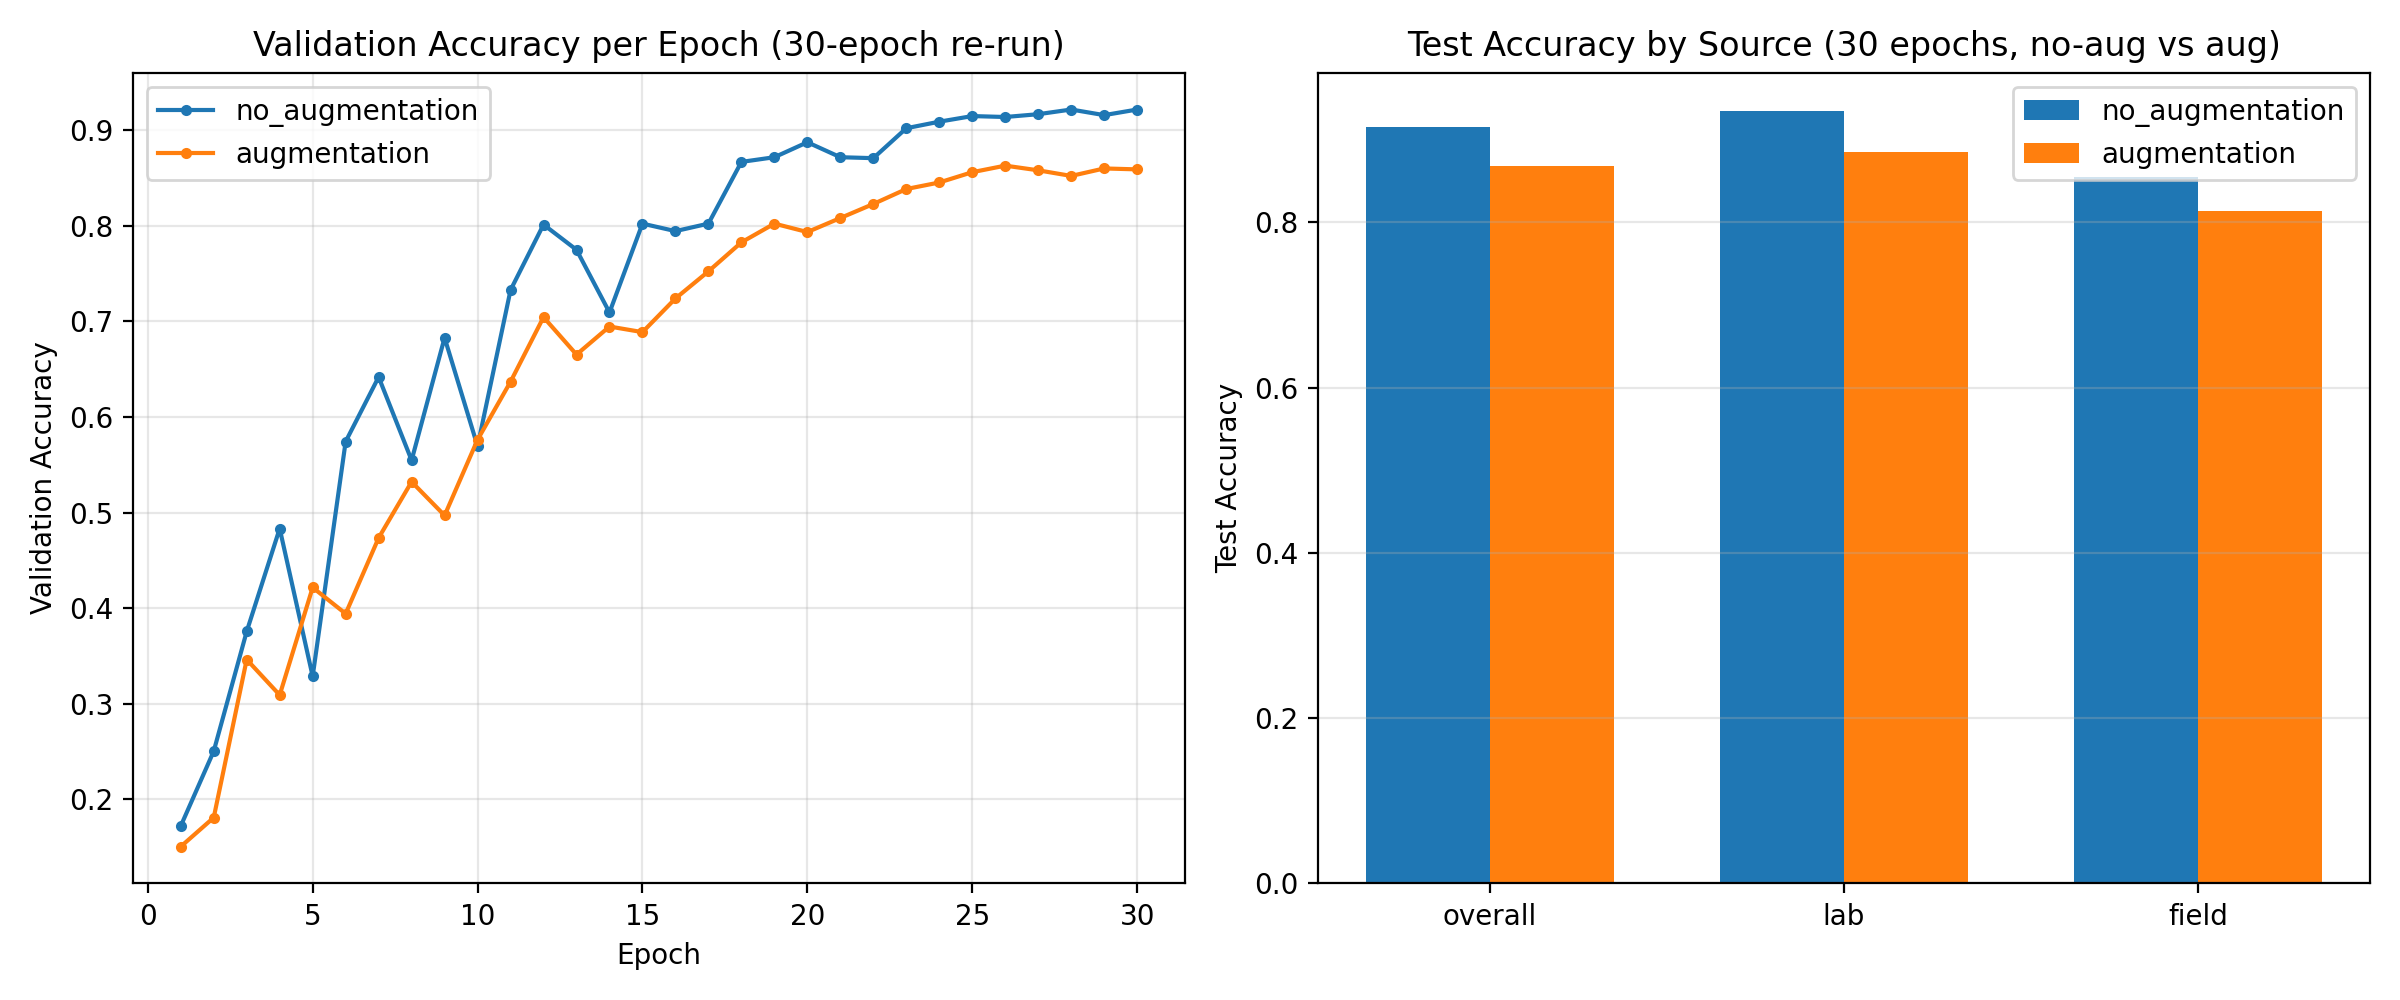

In [3]:
display(Image(filename=str(REPO_ROOT / "report/figures/data/augmentation_ablation.png")))

## Conclusion

At 30 epochs, **no-augmentation still finishes ahead of augmentation, but the gap has narrowed a
lot**: overall test accuracy 91.5% (no-aug) vs 86.8% (aug) — a 4.7 percentage-point gap, down from
10.4 points at the 10-epoch budget. Macro-F1 shows the same pattern (91.6% vs 87.4%). The
validation-accuracy curves (above) make the mechanism visible: the augmented run tracks a few
points below the no-augmentation run at almost every epoch, and both curves are still rising at
epoch 30 rather than having plateaued — consistent with the original hypothesis that augmentation
needed more training time, but not fully consistent with it, since three times the epoch budget
narrowed the gap without closing it.

**Practical takeaway:** for this custom CNN, on this dataset, at reasonable training budgets (10–30
epochs), the current augmentation policy (random crop, horizontal flip, brightness/contrast jitter)
has not shown a net benefit over no augmentation on either overall or field accuracy. Two
directions are open rather than settled:

1. **Train longer still.** Neither curve has clearly plateaued at epoch 30 — it remains possible
   augmentation overtakes no-augmentation with, say, 50+ epochs.
2. **Lighten the augmentation policy.** The current policy may simply be too aggressive for a
   compact 4-block CNN trained from scratch; a milder policy (e.g. flip only, no colour jitter)
   might help sooner without needing a much longer budget.

As before, the lab/field gap persists in both variants regardless of augmentation (no-aug: 93.4%
lab vs 85.5% field; aug: 88.6% lab vs 81.3% field) — the field-robustness problem this project
targets is not something augmentation alone has resolved yet, and remains the more important
open question for member 5's downstream analysis than the augmentation on/off choice itself.